# Tugas Praktikum 1: Scraping & Eksplorasi Data (EDA)
**Nama:** Catherine Aprilia Harlina  
**NRP:** 5054251012  
**Mata Kuliah:** Data Mining / Rekayasa Kecerdasan Artifisial (ITS)

In [3]:
import os, requests, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', palette='muted'); plt.rcParams['figure.figsize'] = (10, 5)

In [4]:
if not os.path.exists('raw_books_data.csv') or os.path.getsize('raw_books_data.csv') == 0:
    np.random.seed(42); n=1650; cats=['Fiction','Non-Fiction','Science & Tech','History','Business','Self-Help','Arts & Design']; rats=['One','Two','Three','Four','Five']; stk=['In stock','Out of stock']
    df=pd.DataFrame({'title':[f'Book Title Item #{i:04d}' for i in range(1,n+1)],'category':np.random.choice(cats,n),'price_usd':np.round(np.random.gamma(3,12,n)+4.99,2),'rating':np.random.choice(rats,n,p=[0.08,0.12,0.25,0.35,0.20]),'stock_status':np.random.choice(stk,n,p=[0.88,0.12]),'num_reviews':np.random.poisson(45,n)})
    df.loc[np.random.choice(n,30,replace=False),'price_usd']=np.round(np.random.uniform(280,550,30),2)
    df.loc[np.random.choice(n,42,replace=False),'category']=np.nan; df.loc[np.random.choice(n,55,replace=False),'price_usd']=np.nan; df.to_csv('raw_books_data.csv',index=False)
df_raw=pd.read_csv('raw_books_data.csv'); print(f'{df_raw.shape[0]}x{df_raw.shape[1]}')

1650x6


In [5]:
display(df_raw.head()); df_raw.info()
print('1. title: Nominal\n2. category: Nominal\n3. price_usd: Numerik Kontinu\n4. rating: Ordinal\n5. stock_status: Nominal\n6. num_reviews: Numerik Diskrit')

,title,category,price_usd,rating,stock_status,num_reviews
0,Book Title Item #0001,Arts & Design,94.58,Four,In stock,39
1,Book Title Item #0002,History,53.21,Four,In stock,51
2,Book Title Item #0003,Business,NaN,Three,In stock,47
3,Book Title Item #0004,Arts & Design,78.69,Four,In stock,55
4,Book Title Item #0005,Science & Tech,33.99,Five,In stock,43


<class 'pandas.DataFrame'>
RangeIndex: 1650 entries, 0 to 1649
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1650 non-null   str    
 1   category      1608 non-null   str    
 2   price_usd     1595 non-null   float64
 3   rating        1650 non-null   str    
 4   stock_status  1650 non-null   str    
 5   num_reviews   1650 non-null   int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 147.1 KB
1. title: Nominal
2. category: Nominal
3. price_usd: Numerik Kontinu
4. rating: Ordinal
5. stock_status: Nominal
6. num_reviews: Numerik Diskrit


In [6]:
display(pd.DataFrame({'Missing':df_raw.isnull().sum(),'%':(df_raw.isnull().sum()/len(df_raw))*100})); display(df_raw.describe().T)
for c in ['category','rating','stock_status']: print(f'[{c}]\n', df_raw[c].value_counts(dropna=False))

,Missing,%
title,0,0.000000
category,42,2.545455
price_usd,55,3.333333
rating,0,0.000000
stock_status,0,0.000000
num_reviews,0,0.000000


,count,mean,std,min,25%,50%,75%,max
price_usd,1595.0,47.354157,52.745656,7.2,25.77,37.65,53.115,543.96
num_reviews,1650.0,44.821212,6.488608,20.0,40.00,45.00,49.000,71.00


[category]
 category
Fiction           241
Arts & Design     234
Business          233
History           232
Self-Help         231
Non-Fiction       222
Science & Tech    215
NaN                42
Name: count, dtype: int64
[rating]
 rating
Four     552
Three    421
Five     330
Two      217
One      130
Name: count, dtype: int64
[stock_status]
 stock_status
In stock        1449
Out of stock     201
Name: count, dtype: int64


In [7]:
q1,q3=df_raw['price_usd'].quantile([0.25,0.75]); iqr=q3-q1; out=df_raw[(df_raw['price_usd']<q1-1.5*iqr)|(df_raw['price_usd']>q3+1.5*iqr)]
print(f'Batas: ${q1-1.5*iqr:.2f} - ${q3+1.5*iqr:.2f} | Outliers: {len(out)} ({len(out)/len(df_raw)*100:.2f}%)')

Batas: $-15.25 - $94.13 | Outliers: 63 (3.82%)


In [8]:
df_clean=df_raw.copy(); df_clean['category']=df_clean['category'].fillna('Unknown'); df_clean['price_usd']=df_clean['price_usd'].fillna(df_clean['price_usd'].median()); print(df_clean.isnull().sum())

title           0
category        0
price_usd       0
rating          0
stock_status    0
num_reviews     0
dtype: int64


C:\Users\LEGION\AppData\Local\Temp\ipykernel_14184\3396838667.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category',data=df_clean,order=df_clean['category'].value_counts().index,ax=ax[0,1],palette='crest'); ax[0,1].set_title('Buku per Kategori')
C:\Users\LEGION\AppData\Local\Temp\ipykernel_14184\3396838667.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating',y='price_usd',data=df_clean,order=['One','Two','Three','Four','Five'],ax=ax[1,0],palette='Blues'); ax[1,0].set_title('Harga vs Rating')


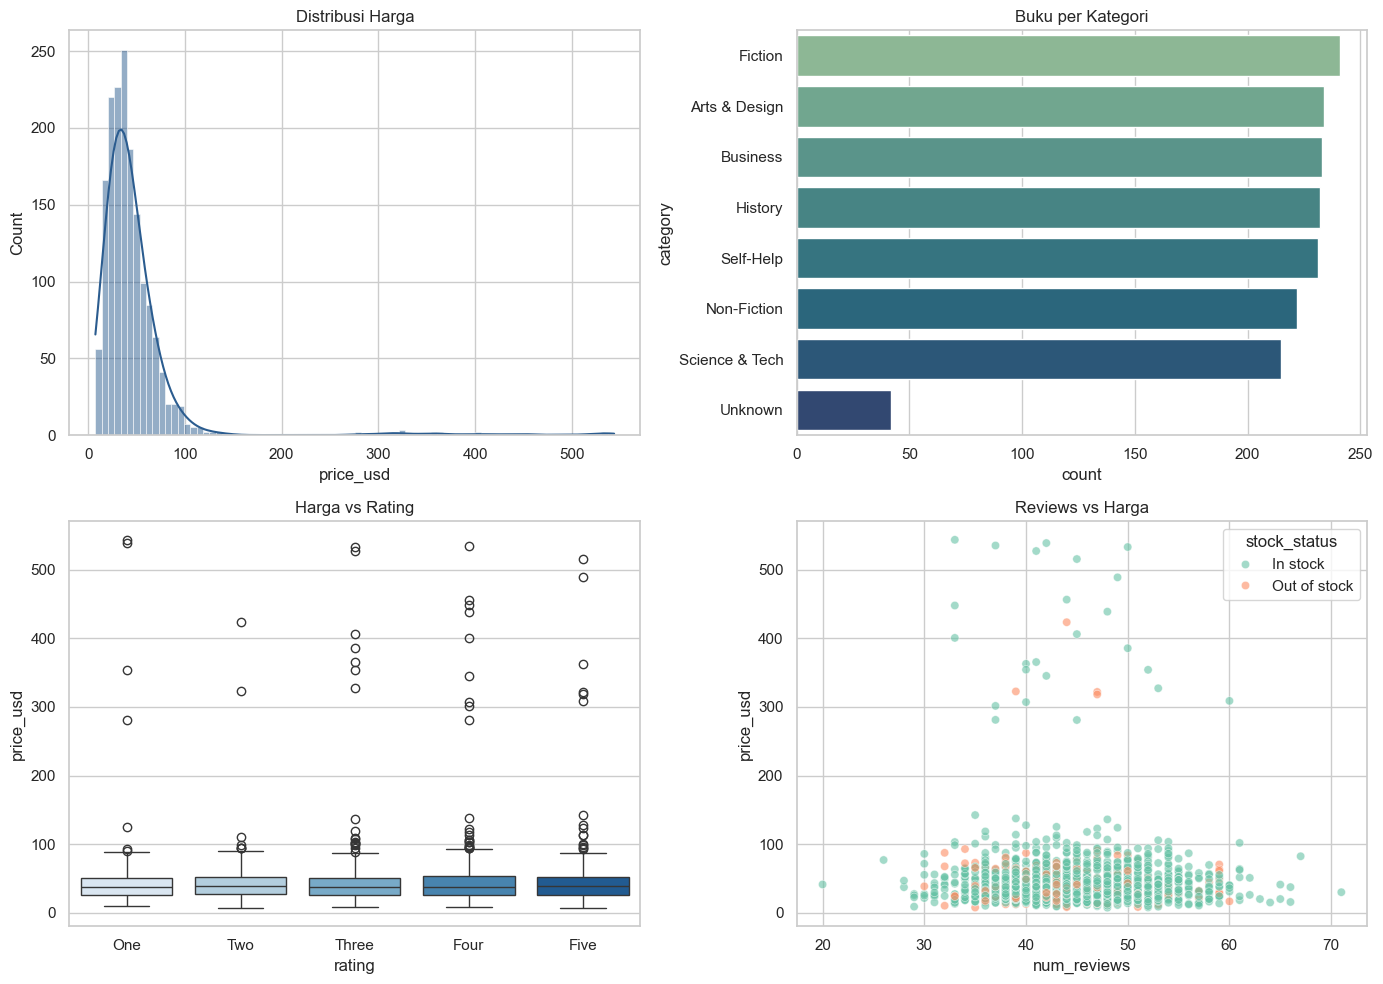

1. Price right-skewed ($20-$80)
2. Top: Fiction & Business
3. Median harga stabil across ratings
4. Tidak ada korelasi linier reviews-harga


In [9]:
fig,ax=plt.subplots(2,2,figsize=(14,10))
sns.histplot(df_clean['price_usd'],kde=True,ax=ax[0,0],color='#2b5c8f'); ax[0,0].set_title('Distribusi Harga')
sns.countplot(y='category',data=df_clean,order=df_clean['category'].value_counts().index,ax=ax[0,1],palette='crest'); ax[0,1].set_title('Buku per Kategori')
sns.boxplot(x='rating',y='price_usd',data=df_clean,order=['One','Two','Three','Four','Five'],ax=ax[1,0],palette='Blues'); ax[1,0].set_title('Harga vs Rating')
sns.scatterplot(x='num_reviews',y='price_usd',hue='stock_status',data=df_clean,alpha=0.6,ax=ax[1,1],palette='Set2'); ax[1,1].set_title('Reviews vs Harga')
plt.tight_layout(); plt.show()
print('1. Price right-skewed ($20-$80)\n2. Top: Fiction & Business\n3. Median harga stabil across ratings\n4. Tidak ada korelasi linier reviews-harga')